#### Idea: To create agentic system which drafts email, check wether the emailokay with user input if "okay" it will ask human approval to send the email else it reitrate and redrafts the email again.

In [2]:
## llm

import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")


d:\python\AI\pynb\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
d:\python\AI\pynb\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [3]:
from typing import TypedDict

class GraphState(TypedDict):
    user_input: str
    email: str
    email_chk: str
    approved: bool


In [4]:
## Nodes
## Email agent 

from langchain.agents import create_agent

EMAIL_AGENT_SYS_PROMPT = """
You are an expert Email Generation Assistant.

Generate clear, well-structured, and grammatically correct emails based on the user's instructions. Adapt the tone (formal, professional, casual, friendly, or empathetic) to match the request.

Include an appropriate subject line, greeting, body, and closing unless the user specifies otherwise. Do not invent missing facts—ask for clarification if essential information is missing.

Return only the email content unless the user requests additional explanation.
"""

def email_agent(state:GraphState):
    agent = create_agent(
        model = llm,
        system_prompt=EMAIL_AGENT_SYS_PROMPT,
    )
    print("Drafting email")
    response = agent.invoke({
        "messages":[
            {
                "role": "user",
                "content": state["user_input"]
            }
        ]
    })
    
    return {
        "email": response["messages"][-1].content
    }

In [5]:
# state={
#     "user_input": "Help me drap a fromal regination mail from my current organisation TCS",
# }

# resp = email_agent(state)

# resp["messages"][-1].pretty_print()

In [6]:
## Reviewer
import json

EMAIL_REVIEWER_SYS_PROMPT = """
You are an Email Reviewer.

Review the drafted email to ensure it is complete, clear, and professionally written.

Verify that:
- The email matches the user's intent.
- The subject, greeting, body.
- The content is grammatically correct and coherent.
- No essential information is missing.

If the email meets these requirements, return "Good". Otherwise, return "Rework".

Return only the following JSON:

{
    "email_chk": "Good" | "Rework"
}
"""

def email_review_agent(state:GraphState):
    agent = create_agent(
        model = llm,
        system_prompt=EMAIL_REVIEWER_SYS_PROMPT,
    )
    print("Reviewing the email")
    print(state['email'])
    response = agent.invoke({
        "messages":[
            {
                "role": "user",
                "content":f"User intent: {state['user_input']} \
                            Draft email: {state['email']}"
            }
        ]
    })

    di = json.loads(response["messages"][-1].content)

    return {
        "email_chk":di["email_chk"]
    }

In [7]:
# state={
#     "user_input": "Write a happy bithday mail to RAM, by Suganth",
# }

# state = state | email_agent(state)

# resp = email_review_agent(state)

# resp["messages"][-1].pretty_print()

In [8]:
## Human review

from langgraph.types import Command, interrupt

def human_review(state:GraphState):
    print(state["email"])
    
    response = interrupt(
        {
            "email_draft": state["email"],
            "message": "Could you please approve the mail?"
        }
    )

    print(response)

    return {
        "approved":response["approved"]
    }

#### What interrupt() does

It does not wait like Python's input().

Instead, it tells LangGraph:

Stop the graph here.

Internally it does something like:


Current Node = human_review

Current State =
{
    "user_input": "...",
    "email": "...",
    "email_chk": "Good"
}

Next line to execute:
approval = interrupt(...)


#### A subtle but important point

interrupt() doesn't literally "pause the Python function" in memory. <b>The current function call ends when the graph interrupts.</b> What gets saved is the graph state, execution position, and checkpoint metadata. <b>When you resume, LangGraph reconstructs the execution context from the checkpoint and continues the node from the interruption point as if interrupt() had returned the value you supplied</b>. This is why the workflow can survive process restarts and long delays between the interrupt and the human response.

In [9]:
def send_mail(state:GraphState):
    if state["approved"]:
        print("Sending email.....")
    else:
        print("Disgarding the plan...")
        

In [10]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(GraphState)

graph_builder.add_node('email_agent', email_agent)
graph_builder.add_node('email_review_agent', email_review_agent)
graph_builder.add_node('human_review', human_review)
graph_builder.add_node('send_mail', send_mail)

In [11]:
def route(state:GraphState):
    if state["email_chk"] == "Good":
        return "human_review"
    else:
        return "email_agent"

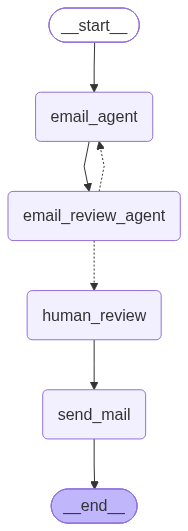

In [12]:
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

graph_builder.add_edge(START, 'email_agent')
graph_builder.add_edge('email_agent', 'email_review_agent')
graph_builder.add_conditional_edges(
    'email_review_agent',
    route,
    {
        "human_review":"human_review",
        "email_agent":"email_agent"
    }
)
graph_builder.add_edge('human_review', 'send_mail')
graph_builder.add_edge('send_mail', END)

mem_saver = MemorySaver()
graph = graph_builder.compile(checkpointer=mem_saver)
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
user_input = "Write a happy bithday mail to RAM, by Suganth"
config = {"configurable":{"thread_id":"1"}}

events = graph.stream(
    {'user_input':user_input},
    config=config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

Drafting email
Reviewing the email
Subject: Wishing You a Joyous Birthday, RAM!

Dear RAM,

I wanted to take a moment to wish you a very happy birthday! On this special day, I hope you're surrounded by love, laughter, and all your favorite things. You deserve to be celebrated and I'm honored to be a part of it.

Here's to another year of adventures, achievements, and making unforgettable memories. May your birthday be as bright and amazing as you are. I hope your day is filled with joy, cheer, and all the things that bring you happiness.

Sending you lots of love, best wishes, and warm birthday greetings. Have a fantastic day and a wonderful year ahead!

Warm regards,
Suganth
Subject: Wishing You a Joyous Birthday, RAM!

Dear RAM,

I wanted to take a moment to wish you a very happy birthday! On this special day, I hope you're surrounded by love, laughter, and all your favorite things. You deserve to be celebrated and I'm honored to be a part of it.

Here's to another year of adventures

In [14]:
human_input = bool(input("Agent: Can I sent mail?"))
human_cmd = Command(resume={"approved":human_input})
events = graph.stream(human_cmd, config=config, stream_mode='values')
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

Subject: Wishing You a Joyous Birthday, RAM!

Dear RAM,

I wanted to take a moment to wish you a very happy birthday! On this special day, I hope you're surrounded by love, laughter, and all your favorite things. You deserve to be celebrated and I'm honored to be a part of it.

Here's to another year of adventures, achievements, and making unforgettable memories. May your birthday be as bright and amazing as you are. I hope your day is filled with joy, cheer, and all the things that bring you happiness.

Sending you lots of love, best wishes, and warm birthday greetings. Have a fantastic day and a wonderful year ahead!

Warm regards,
Suganth
{'approved': True}
Sending email.....


In [ ]:
# Helps in debugging and triubshooting.

# state = graph.get_state(config)

# graph.invoke()       → Execute
# graph.get_state()    → Inspect current checkpoint
# graph.get_state_history() → Inspect previous checkpoints
# Command(resume=...)  → Resume interrupted execution